In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
from tqdm.auto import tqdm
import jax.numpy as jnp
import matplotlib.pyplot as plt
import odds_datasets

0it [00:00, ?it/s]

2024-03-31 01:09:31.795710: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


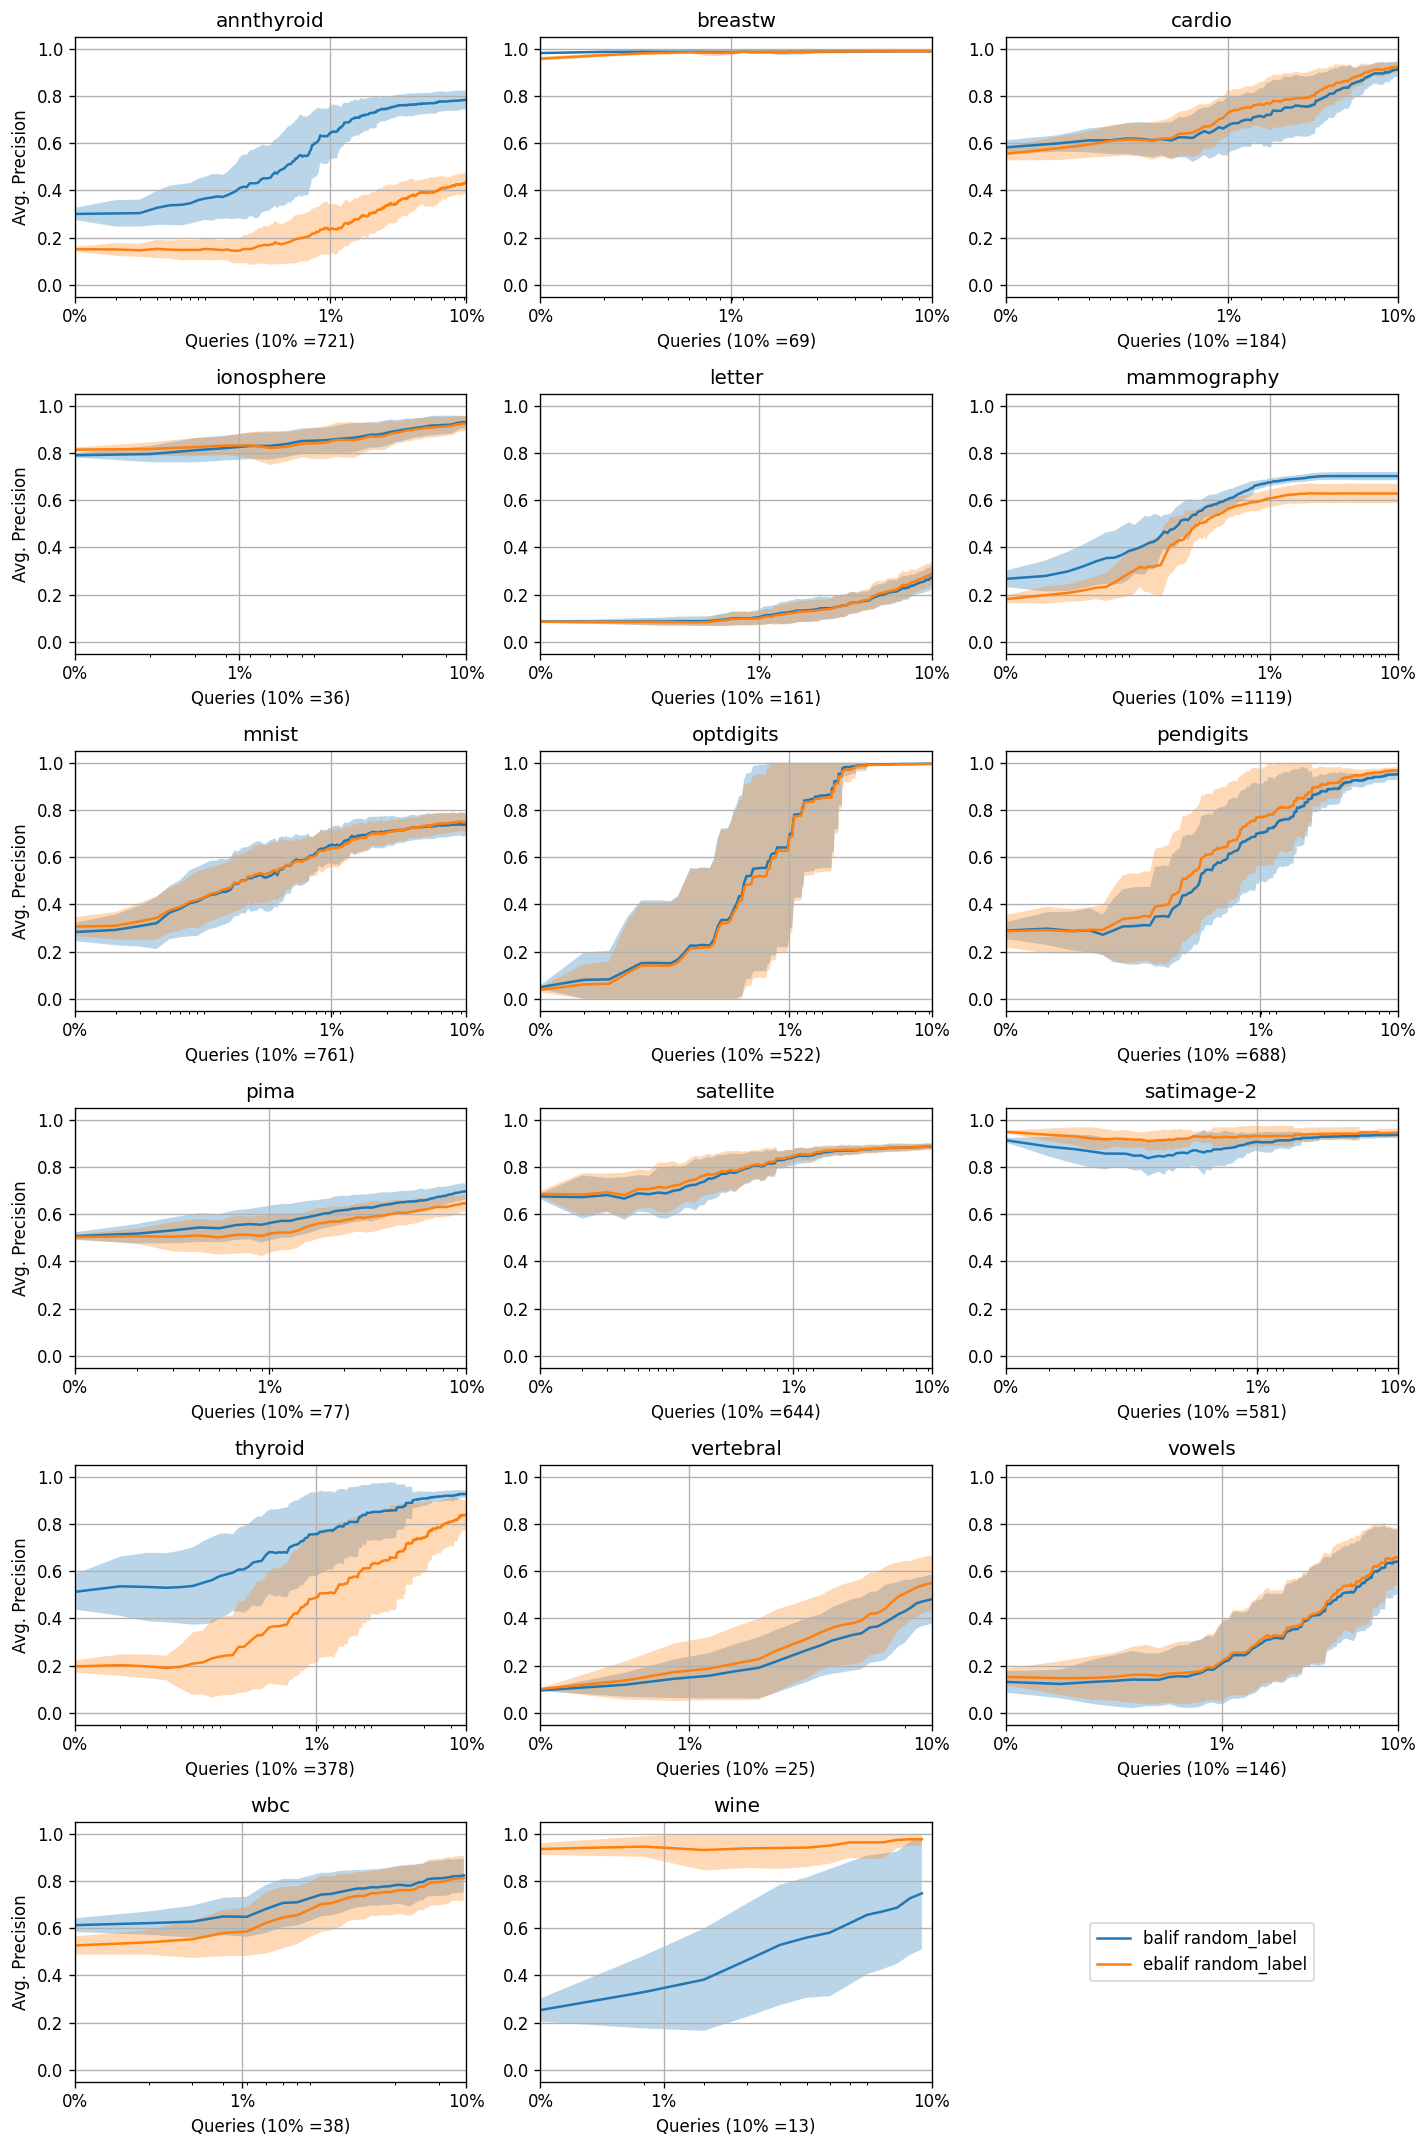

In [2]:
plt.figure(figsize=(2 * 6, 3 * 6), dpi=120)
for i, dataset_name in tqdm(enumerate(sorted(odds_datasets.datasets_names) + ["legend"])):
    plt.subplot(6, 3, i + 1)
    # for hyperplane_components, label_batch_size in zip([1, 1, None, None], [8, 1, 8, 1]):
    for hyperplane_components, label_batch_size in zip([1, None], [1, 1]):
        if dataset_name == "legend":
            # plt.plot(0, 0, label=f"{'e' if hyperplane_components!=1 else ''}balif {label_batch_size=}")
            plt.plot(0, 0, label=f"{'e' if hyperplane_components!=1 else ''}balif random_label")
        else:
            ap = jnp.load(
                f"results/{dataset_name}_balif_{hyperplane_components=}_{label_batch_size=}.npy",
                allow_pickle=True,
            )
            ap_mean, ap_std = ap.mean(axis=0), ap.std(axis=0)
            plt.semilogx(1 + jnp.arange(len(ap_mean)) * label_batch_size, ap_mean)
            plt.fill_between(
                1 + jnp.arange(len(ap_mean)) * label_batch_size,
                # jnp.maximum(0, ap_mean - ap_std),
                # jnp.minimum(1, ap_mean + ap_std),
                jnp.maximum(0, ap.min(axis=0)),
                jnp.minimum(1, ap.max(axis=0)),
                alpha=0.3,
            )

    if dataset_name == "legend":
        plt.title("")
        plt.legend(loc="center")
        plt.axis("off")
    else:
        plt.title(dataset_name)
        data, labels = odds_datasets.load(dataset_name)
        #if i >= 14:
        plt.xlabel(f"Queries (10% ={1+len(data)//10})")
        if i % 3 == 0:
            plt.ylabel("Avg. Precision")
        plt.ylim(-0.05, 1.05)
        plt.xlim(1, 1 + data.shape[0] / 10)
        plt.xticks([1, 1 + data.shape[0] / 100, 1 + data.shape[0] / 10], labels=["0%", "1%", "10%"])
        plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        plt.grid()

plt.tight_layout()
plt.savefig(f"figures/ap_evolution/ap_all.pdf", bbox_inches="tight")
plt.show()